In [1]:
import sys
import os

# Required for Windows multiprocessing
if __name__ == '__main__':
    import multiprocessing
    multiprocessing.freeze_support()
    
    # Prevent workers from re-executing notebook cells
    if multiprocessing.current_process().name != 'MainProcess':
        sys.exit(0)

# Also helps on Windows
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

print("Multiprocessing protection initialized")

Multiprocessing protection initialized


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

import cv2

import torch
from torch.utils.data import DataLoader
from torchvision import models, transforms
import torch.nn as nn
import torchvision.transforms.functional as F
from torch.amp import autocast, GradScaler

from tqdm.notebook import tqdm
from PIL import Image

from data_loader import NIH8Dataset, train_data_transforms, val_data_transforms
from utils import *
from config import *

In [3]:
# Configurations

# Paths, Directories
print(f"CSV Path: {CSV_PATH}")
print(f"Image Folders: {IMAGE_FOLDERS}")

# Get device
device = get_device()
print(f"\nUsing device: {device}")

CSV Path: d:\DSC Downloads\NIH-XRay-Segmentation\data\Data_Entry_2017.csv
Image Folders: [WindowsPath('d:/DSC Downloads/NIH-XRay-Segmentation/images')]

Using device: cuda


In [4]:
# Patient-wise split
print("1. Loading CSV and Splitting by Patient...")
df = pd.read_csv(CSV_PATH)
train_df, val_df = get_train_val_split(df, train_size=0.8, random_state=42)

# Image folders 
folders = [str(IMAGE_FOLDERS[0] / f"images_{str(i).zfill(3)}") for i in range(1, 13)]


print("\n2. Initializing Train and Validation Datasets")
train_ds = NIH8Dataset(train_df, folders, subset_size=TRAIN_SUBSET_SIZE, transform=train_data_transforms, cache_path=CACHE_PATH)
val_ds   = NIH8Dataset(val_df,   folders, subset_size=VAL_SUBSET_SIZE, transform=val_data_transforms, cache_path=CACHE_PATH)

train_loader = DataLoader(train_ds, batch_size=TRAIN_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, persistent_workers=PERSISTENT_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=PERSISTENT_WORKERS, pin_memory=True)

num_classes = len(train_ds.classes)
print(f"\nDataset initialization complete!")
print(f"  Classes: {num_classes}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

1. Loading CSV and Splitting by Patient...
Split complete: 89826 train images, 22294 val images.

2. Initializing Train and Validation Datasets
Found 15 unique pathologies: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Loading image paths from cache: path_cache.json

DATASET SUMMARY
Total images:     89,826
Unique patients:  24,644
Pathologies:      15

Found 15 unique pathologies: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Loading image paths from cache: path_cache.json

DATASET SUMMARY
Total images:     22,294
Unique patients:  6,161
Pathologies:      15


Dataset initialization complete!
  Classes: 15
  Train batches: 702
  Val batches: 175


In [5]:
# Model Initialization, using ResNet50 
print("\n3. Initializing Model...")
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes) # Replace final layer for NIH finding classes
model = model.to(device)

# Sanity check: Test forward pass
with torch.no_grad():
    dummy = torch.randn(2, 3, 256, 256).to(device)
    out = model(dummy)
    assert out.shape == torch.Size([2, num_classes]), f"Expected [{2}, {num_classes}], got {out.shape}"
    print(f"Model sanity check passed: input {dummy.shape} → output {out.shape}")



3. Initializing Model...
Model sanity check passed: input torch.Size([2, 3, 256, 256]) → output torch.Size([2, 15])


In [6]:
print(f"\n4. Setting up Loss and Optimizer...")

weights, weight_dict = calculate_class_weights(train_ds, max_weight=MAX_CLASS_WEIGHT)
weights = weights.to(device)
print(f"Class weights calculated for {len(weight_dict)} classes.")
print("Class weights:")
for i, (class_name, weight) in enumerate(weight_dict.items()):
    print(f"  {class_name}: {weight:.2f}")
print(f"Weight range: [{weights.min():.2f}, {weights.max():.2f}]")

# Loss and Optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=weights) # Use pos_weight to handle class imbalance in multi-label classification
optimizer = torch.optim.AdamW([
    {'params': model.fc.parameters(), 'lr': LEARNING_RATE},
    {'params': model.layer4.parameters(), 'lr': 1e-5}, # Fine-tuning only the last block and the fully connected layer
], weight_decay=WEIGHT_DECAY) # Weight decay for preventing overfitting 

# Mixed precision scaler (if enabled)
scaler = GradScaler("cuda") if USE_AMP and device.type == "cuda" else None

if USE_AMP and scaler:
    print("\nMixed precision training enabled")



4. Setting up Loss and Optimizer...
Class weights calculated for 15 classes.
Class weights:
  Atelectasis: 8.61
  Cardiomegaly: 10.00
  Consolidation: 10.00
  Edema: 10.00
  Effusion: 7.34
  Emphysema: 10.00
  Fibrosis: 10.00
  Hernia: 10.00
  Infiltration: 4.69
  Mass: 10.00
  No Finding: 0.86
  Nodule: 10.00
  Pleural_Thickening: 10.00
  Pneumonia: 10.00
  Pneumothorax: 10.00
Weight range: [0.86, 10.00]

Mixed precision training enabled


In [7]:
def train_one_epoch(epoch):
    model.train()
    running_loss, n = 0.0, 0

    use_cuda = (device.type == "cuda")
    use_amp  = bool(USE_AMP and use_cuda and scaler is not None)

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)

    for batch in pbar:
        if batch is None:
            continue  # ideally remove by filtering dataset

        # Move to device (non_blocking only helps with CUDA + pin_memory=True)
        x = batch["image"].to(device, non_blocking=use_cuda)
        y = batch["labels"].to(device, non_blocking=use_cuda)

        # Debug guards: catch first NaN/Inf early
        if not torch.isfinite(x).all():
            raise ValueError("NaN/Inf found in input batch x")
        if not torch.isfinite(y).all():
            raise ValueError("NaN/Inf found in labels batch y")

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = model(x)
                if not torch.isfinite(logits).all():
                    raise ValueError("NaN/Inf found in logits (forward pass)")
                loss = criterion(logits, y)

            if not torch.isfinite(loss):
                raise ValueError(f"NaN/Inf loss detected (AMP). loss={loss.item()}")

            scaler.scale(loss).backward()

            # Grad clip must be done on unscaled grads
            if GRAD_CLIP:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

            scaler.step(optimizer)
            scaler.update()

        else:
            logits = model(x)
            if not torch.isfinite(logits).all():
                raise ValueError("NaN/Inf found in logits (forward pass)")
            loss = criterion(logits, y)

            if not torch.isfinite(loss):
                raise ValueError(f"NaN/Inf loss detected. loss={loss.item()}")

            loss.backward()

            if GRAD_CLIP:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

            optimizer.step()

        running_loss += loss.item() * x.size(0)
        n += x.size(0)

        pbar.set_postfix(loss=(running_loss / max(n, 1)))

    return running_loss / max(n, 1)

@torch.no_grad()
def validate(epoch):
    model.eval()
    running_loss, n = 0.0, 0
    all_labels, all_probs = [], []

    pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]", leave=False)
    for batch in pbar:
        if batch is None:
            continue

        x = batch["image"].to(device, non_blocking=True)
        y = batch["labels"].to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)
        probs = torch.sigmoid(logits)

        running_loss += loss.item() * x.size(0)
        n += x.size(0)

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        

    all_labels = np.concatenate(all_labels, axis=0) if all_labels else np.zeros((0, num_classes))
    all_probs  = np.concatenate(all_probs, axis=0)  if all_probs  else np.zeros((0, num_classes))

    metrics = calculate_metrics(all_labels, all_probs, threshold=0.5, class_names=train_ds.classes)
    return running_loss / max(n, 1), metrics

In [8]:
#Run training + save best 

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)

best_auc = -1.0

history = {
    "train_loss": [],
    "val_loss": [],
    "mean_auc": []
}

for epoch in range(EPOCHS):
    tr_loss = train_one_epoch(epoch)
    va_loss, metrics = validate(epoch)

    mean_auc = metrics['auc_macro'] if metrics['auc_macro'] is not None else 0.0

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["mean_auc"].append(mean_auc)

    # Print every 5 epochs or on the first/last epoch
    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == EPOCHS - 1:
        print(f"\nEpoch {epoch+1}/{EPOCHS} Summary:")
        print(f"  Train Loss: {tr_loss:.4f}")
        print(f"  Val Loss:   {va_loss:.4f}")
        print(f"  Mean AUC:   {mean_auc:.4f}")
        print(f"  Valid Classes: {metrics['num_valid_classes']}/{num_classes}")
        print("-" * 50)

    if mean_auc > best_auc:
        best_auc = mean_auc
        save_checkpoint({
            "epoch": epoch,
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scaler": scaler.state_dict() if scaler else None,
            "best_auc": best_auc,
            "history": history
        }, filename=MODEL_SAVE_PATH)

print(f"\n{'='*60}")
print(f"TRAINING COMPLETE")
print(f"{'='*60}")
print(f"Best Mean AUC: {best_auc:.4f}")



STARTING TRAINING


Epoch 1/30 [Train]:   0%|          | 0/702 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/175 [00:00<?, ?it/s]


Epoch 1/30 Summary:
  Train Loss: 0.7189
  Val Loss:   0.6834
  Mean AUC:   0.7082
  Valid Classes: 15/15
--------------------------------------------------
=> Saving checkpoint: best_resnet50_nih_TEST3.pt (Epoch 0)


Epoch 2/30 [Train]:   0%|          | 0/702 [00:00<?, ?it/s]

...

Epoch 29/30 [Train]:   0%|          | 0/702 [00:00<?, ?it/s]

Epoch 29/30 [Val]:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 30/30 [Train]:   0%|          | 0/702 [00:00<?, ?it/s]

Epoch 30/30 [Val]:   0%|          | 0/175 [00:00<?, ?it/s]


Epoch 30/30 Summary:
  Train Loss: 0.4502
  Val Loss:   0.7236
  Mean AUC:   0.7731
  Valid Classes: 15/15
--------------------------------------------------

TRAINING COMPLETE
Best Mean AUC: 0.7868


In [14]:
# Final evaluation - run after training

# Load best model
print("\nLoading best model for final evaluation...")
checkpoint = torch.load(MODEL_SAVE_PATH, weights_only=False)
model.load_state_dict(checkpoint['state_dict'])

# Final validation
_, final_metrics = validate(epoch=0)

# Print detailed metrics 
print("\n" + "="*60)
print("FINAL EVALUATION METRICS")
print("="*60)
print_metrics(final_metrics, train_ds.classes, show_invalid=True)


Loading best model for final evaluation...


Epoch 1/30 [Val]:   0%|          | 0/175 [00:00<?, ?it/s]


FINAL EVALUATION METRICS
Class                            AUC    Precision     Recall         F1
------------------------------------------------------------------------------------------
Atelectasis                   0.7663       0.1975     0.7109     0.3091
Cardiomegaly                  0.8535       0.2071     0.4159     0.2765
Consolidation                 0.7819       0.1297     0.4763     0.2038
Edema                         0.8710       0.1280     0.4493     0.1992
Effusion                      0.8430       0.3047     0.7462     0.4327
Emphysema                     0.8787       0.2761     0.4388     0.3389
Fibrosis                      0.7576       0.0958     0.0879     0.0917
Hernia                        0.8650       0.0000     0.0000     0.0000
Infiltration                  0.6863       0.3044     0.5533     0.3928
Mass                          0.7486       0.1651     0.4126     0.2359
No Finding                    0.7472       0.7152     0.7062     0.7107
Nodule             

In [10]:
# # Manual save at the end just in case
# save_checkpoint({
#             "epoch": epoch,
#             "state_dict": model.state_dict(),
#             "optimizer": optimizer.state_dict(),
#             "best_auc": best_auc
#         }, filename="best_resnet50_nih.pt")

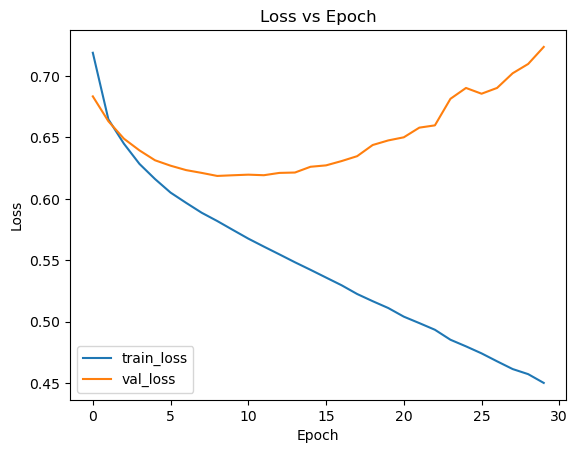

In [15]:
plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

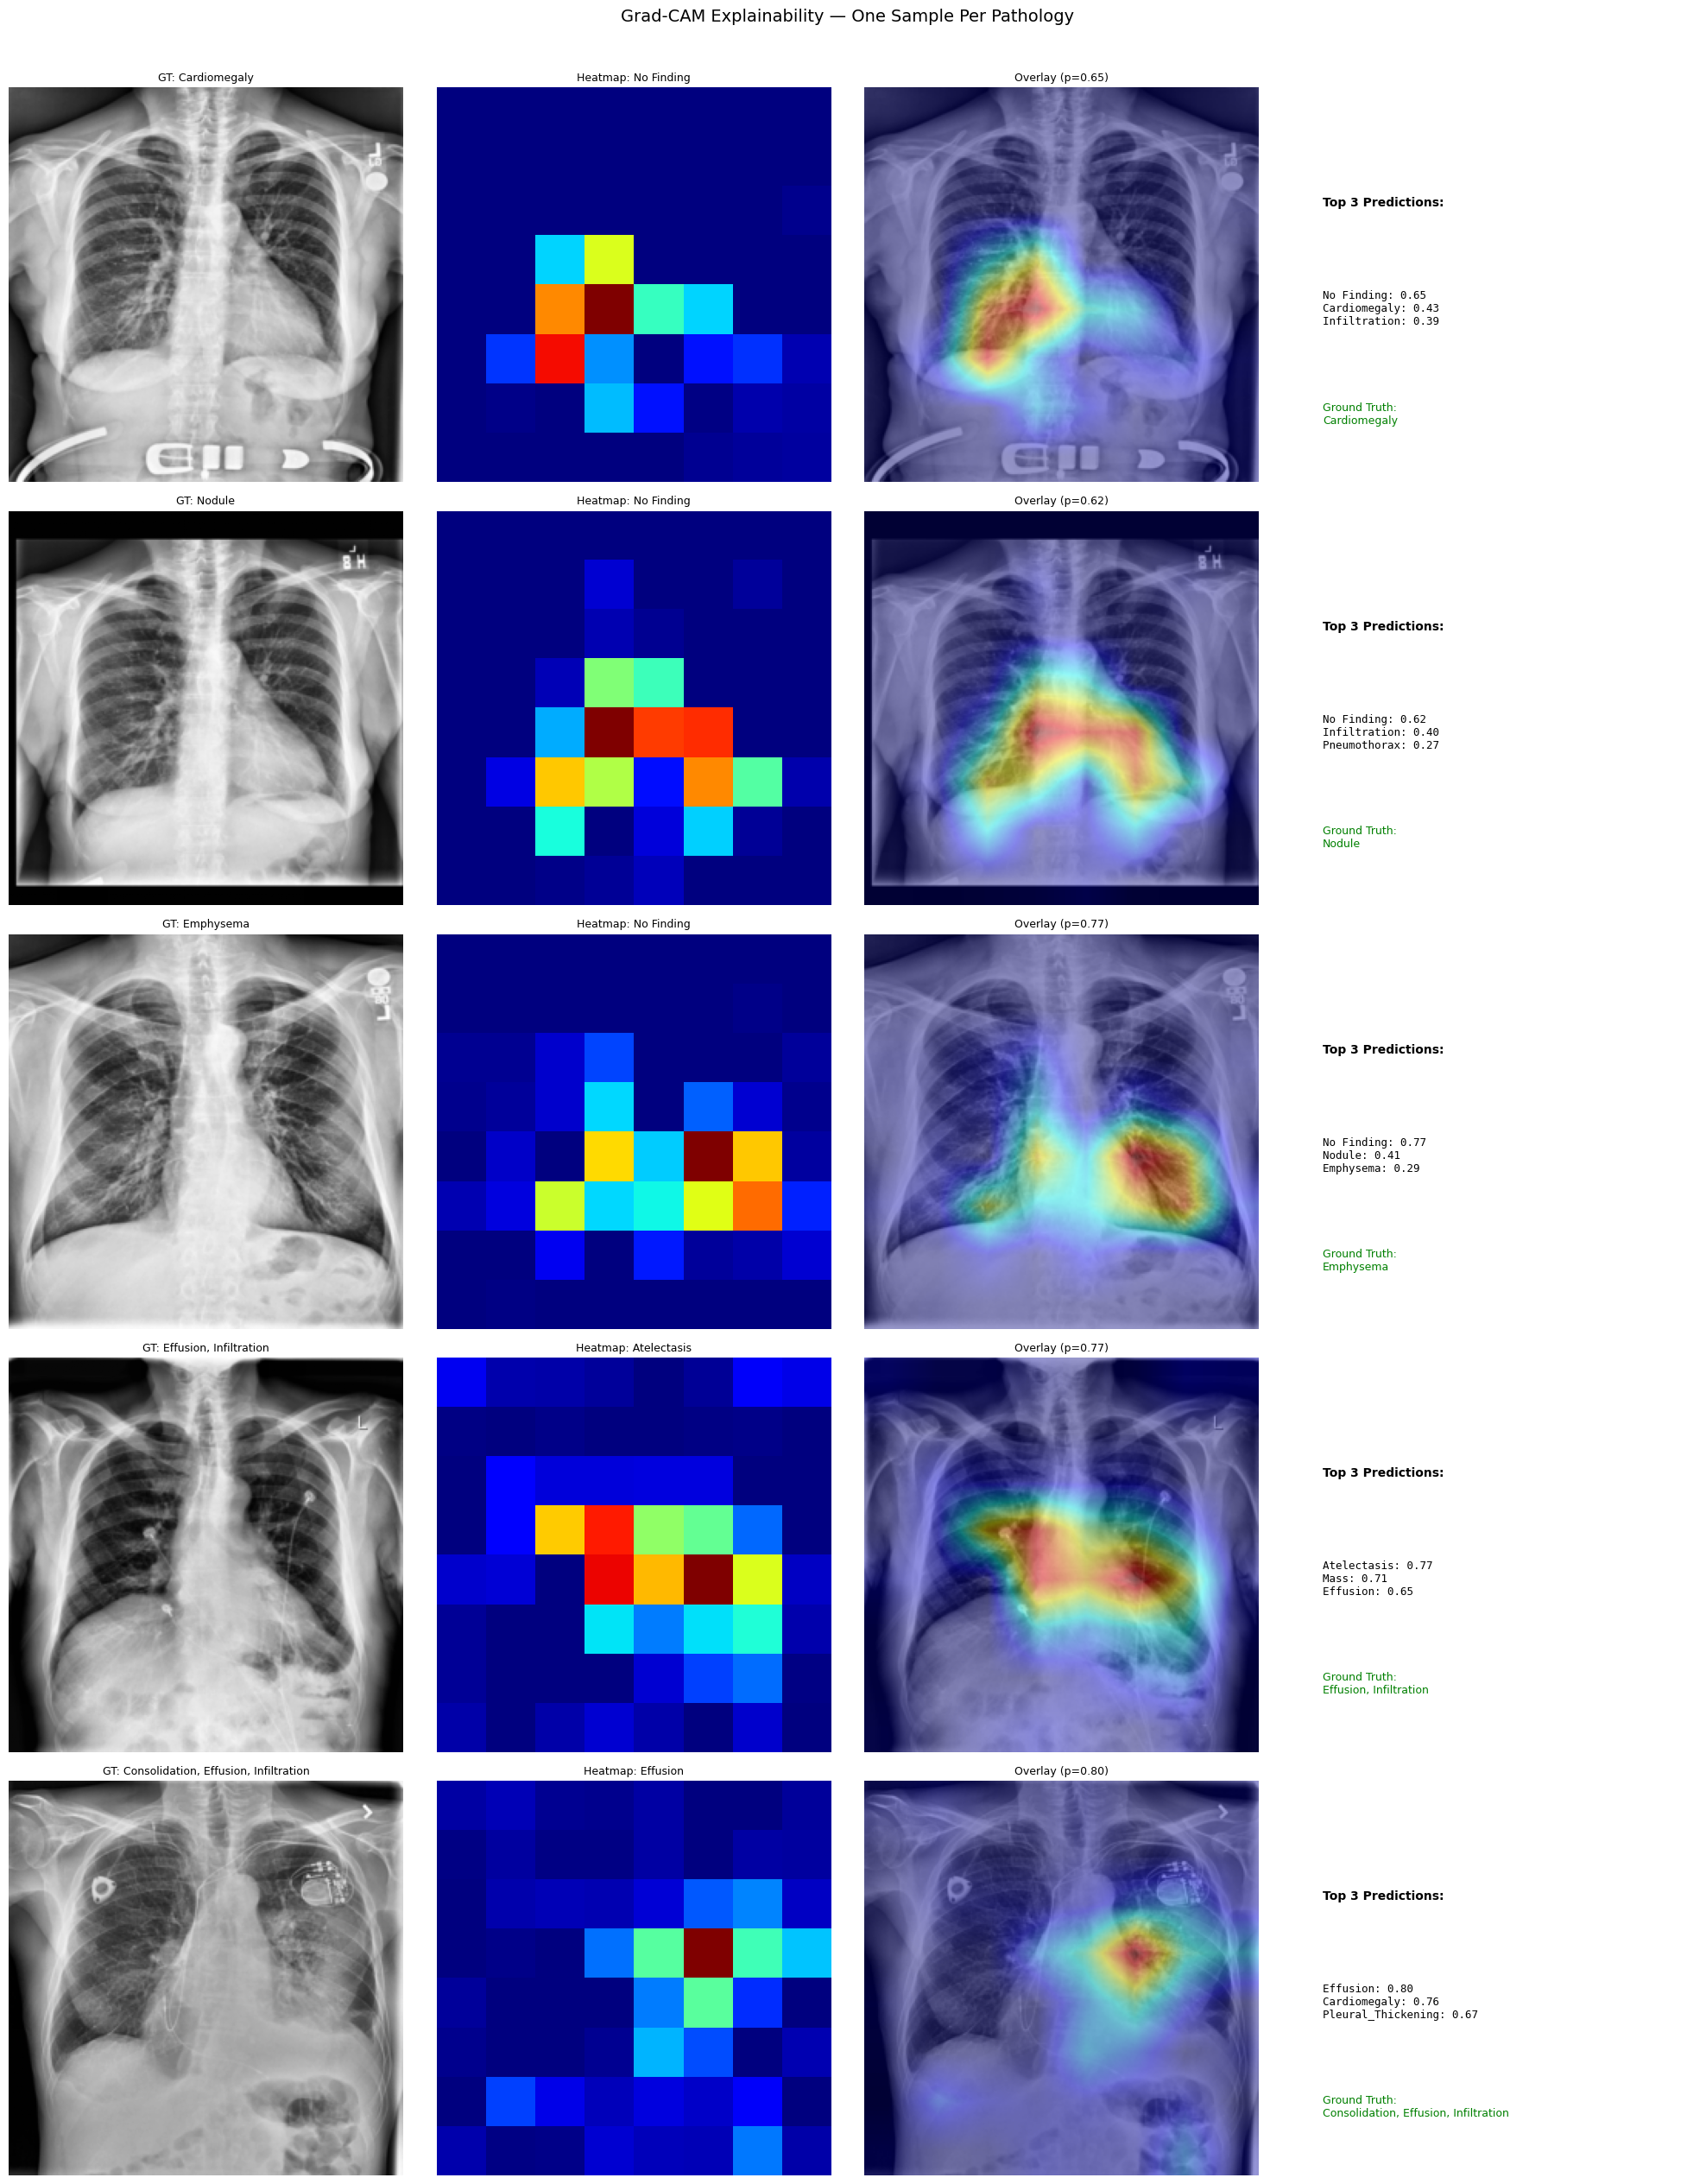

Pathologies shown: Cardiomegaly, Nodule, Consolidation, Emphysema, Effusion


In [16]:
# Exploration with Grad-CAM, sampling one image per pathology for visualization, LLM for initial setup prior to domain application

target_layer = model.layer4[-1]
cam = GradCAM(model, target_layer)

# Load the best model before visualizing
checkpoint = torch.load(MODEL_SAVE_PATH, weights_only=False)
model.load_state_dict(checkpoint["state_dict"])
model.eval()

# Find one image per unique pathology
shown_classes = set()
samples = []

for idx in range(len(val_ds)):
    sample = val_ds[idx]
    if sample is None:
        continue
    active = [val_ds.classes[j] for j, v in enumerate(sample["labels"]) if v == 1]
    primary = active[0]
    if primary not in shown_classes and primary != "No Finding":
        shown_classes.add(primary)
        samples.append(sample)
    if len(samples) >= 5:
        break

# Fallback: if fewer than 5 pathologies found, fill with any remaining images
if len(samples) < 5:
    for idx in range(len(val_ds)):
        if len(samples) >= 5:
            break
        sample = val_ds[idx]
        if sample is None:
            continue
        active = [val_ds.classes[j] for j, v in enumerate(sample["labels"]) if v == 1]
        primary = active[0]
        if primary not in shown_classes:
            shown_classes.add(primary)
            samples.append(sample)

num_samples = len(samples)
fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))
if num_samples == 1:
    axes = axes[np.newaxis, :]

for i, sample in enumerate(samples):
    input_tensor = sample["image"].unsqueeze(0).to(device)
    labels = sample["labels"]

    # Get predictions
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0].detach().cpu().numpy()

    # Top predicted class
    pred_idx = int(np.argmax(probs))
    pred_name = train_ds.classes[pred_idx]
    pred_prob = probs[pred_idx]

    # Ground truth labels
    gt_labels = [train_ds.classes[j] for j, val in enumerate(labels) if val == 1]

    # Generate heatmap for top prediction
    heatmap = cam.generate_heatmap(input_tensor, pred_idx)

    # Un-normalize the image for display
    img_np = input_tensor[0, 0].detach().cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    img_np = (img_np * 255).astype(np.uint8)

    overlay = overlay_heatmap(heatmap, img_np)

    # Top 3 predictions
    top3_idx = np.argsort(probs)[::-1][:3]
    top3_str = "\n".join([f"{train_ds.classes[j]}: {probs[j]:.2f}" for j in top3_idx])

    # Plot: Original | Heatmap | Overlay | Top 3 Predictions
    axes[i, 0].imshow(img_np, cmap="gray")
    axes[i, 0].set_title(f"GT: {', '.join(gt_labels)}", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(heatmap, cmap="jet")
    axes[i, 1].set_title(f"Heatmap: {pred_name}", fontsize=9)
    axes[i, 1].axis("off")

    axes[i, 2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[i, 2].set_title(f"Overlay (p={pred_prob:.2f})", fontsize=9)
    axes[i, 2].axis("off")

    axes[i, 3].axis("off")
    axes[i, 3].text(0.1, 0.7, "Top 3 Predictions:", fontsize=10, fontweight="bold",
                     transform=axes[i, 3].transAxes)
    axes[i, 3].text(0.1, 0.4, top3_str, fontsize=9, family="monospace",
                     transform=axes[i, 3].transAxes)
    axes[i, 3].text(0.1, 0.15, f"Ground Truth:\n{', '.join(gt_labels)}", fontsize=9,
                     color="green", transform=axes[i, 3].transAxes)

plt.suptitle("Grad-CAM Explainability — One Sample Per Pathology", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Pathologies shown: {', '.join(shown_classes)}")

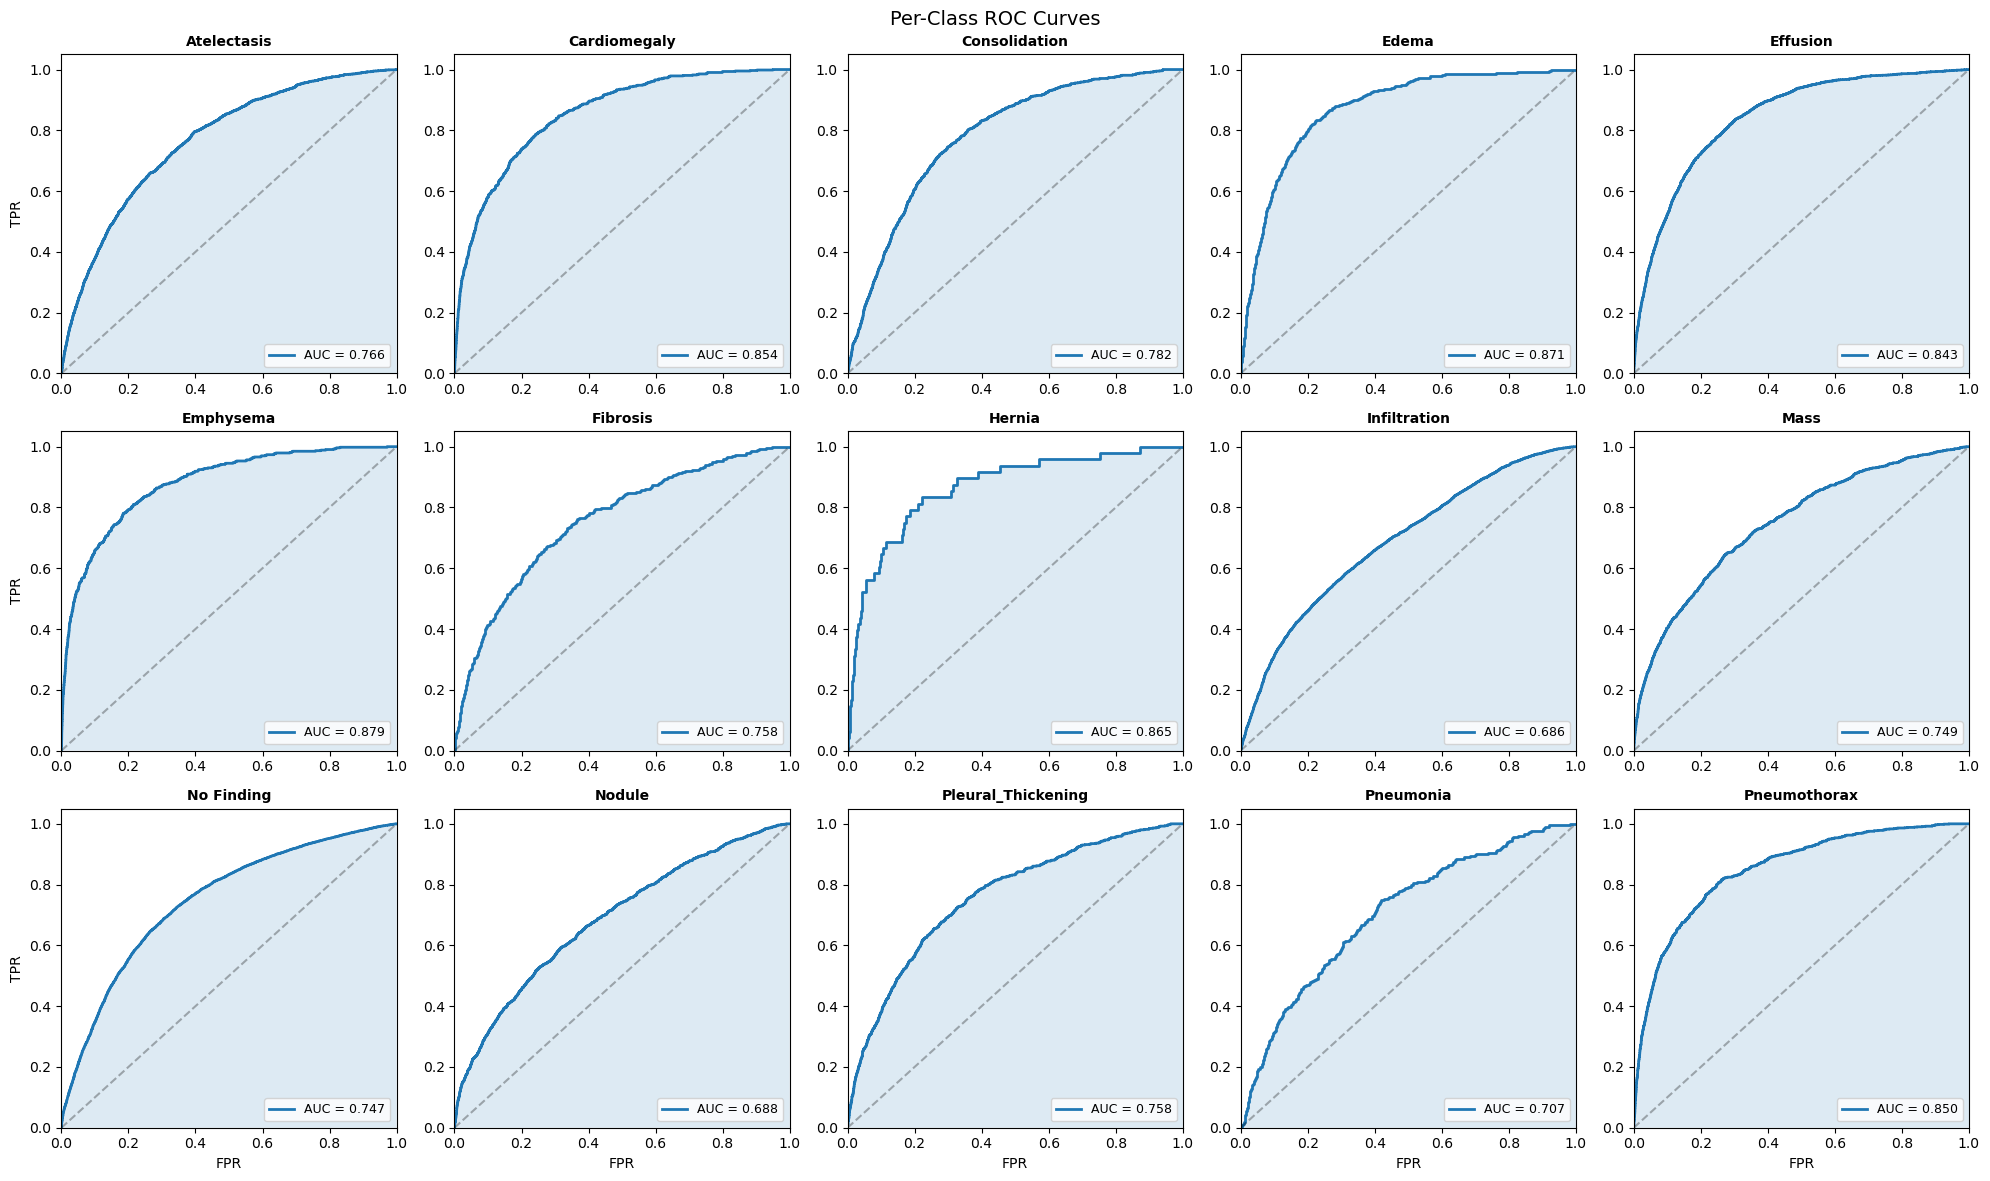

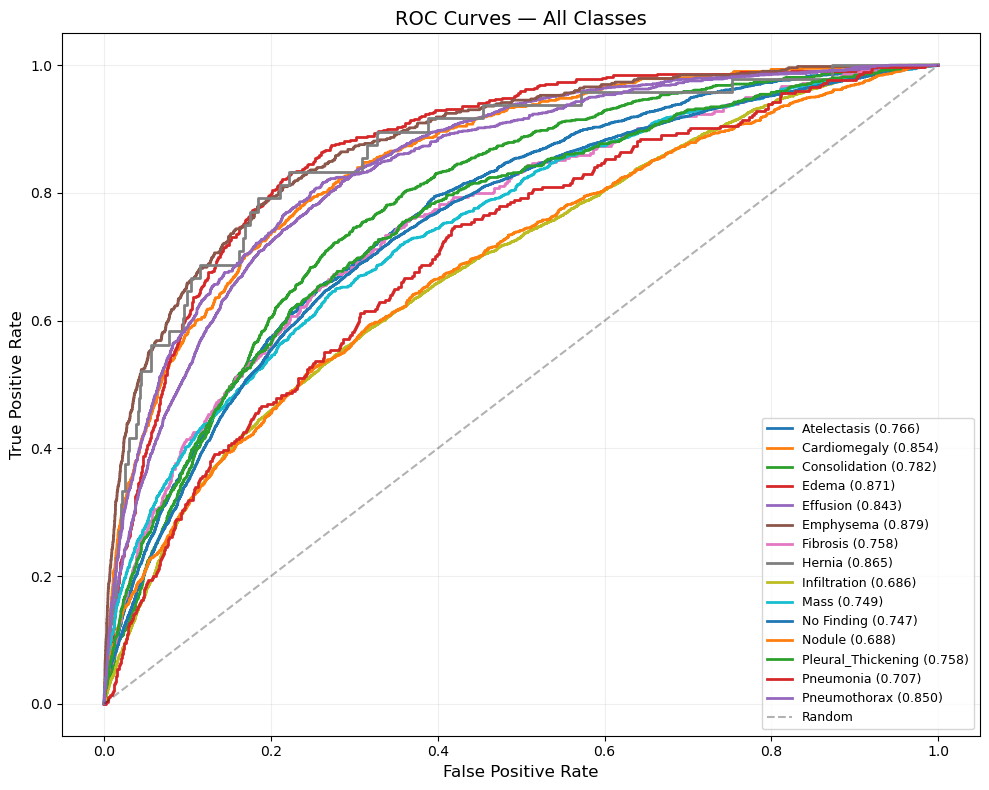

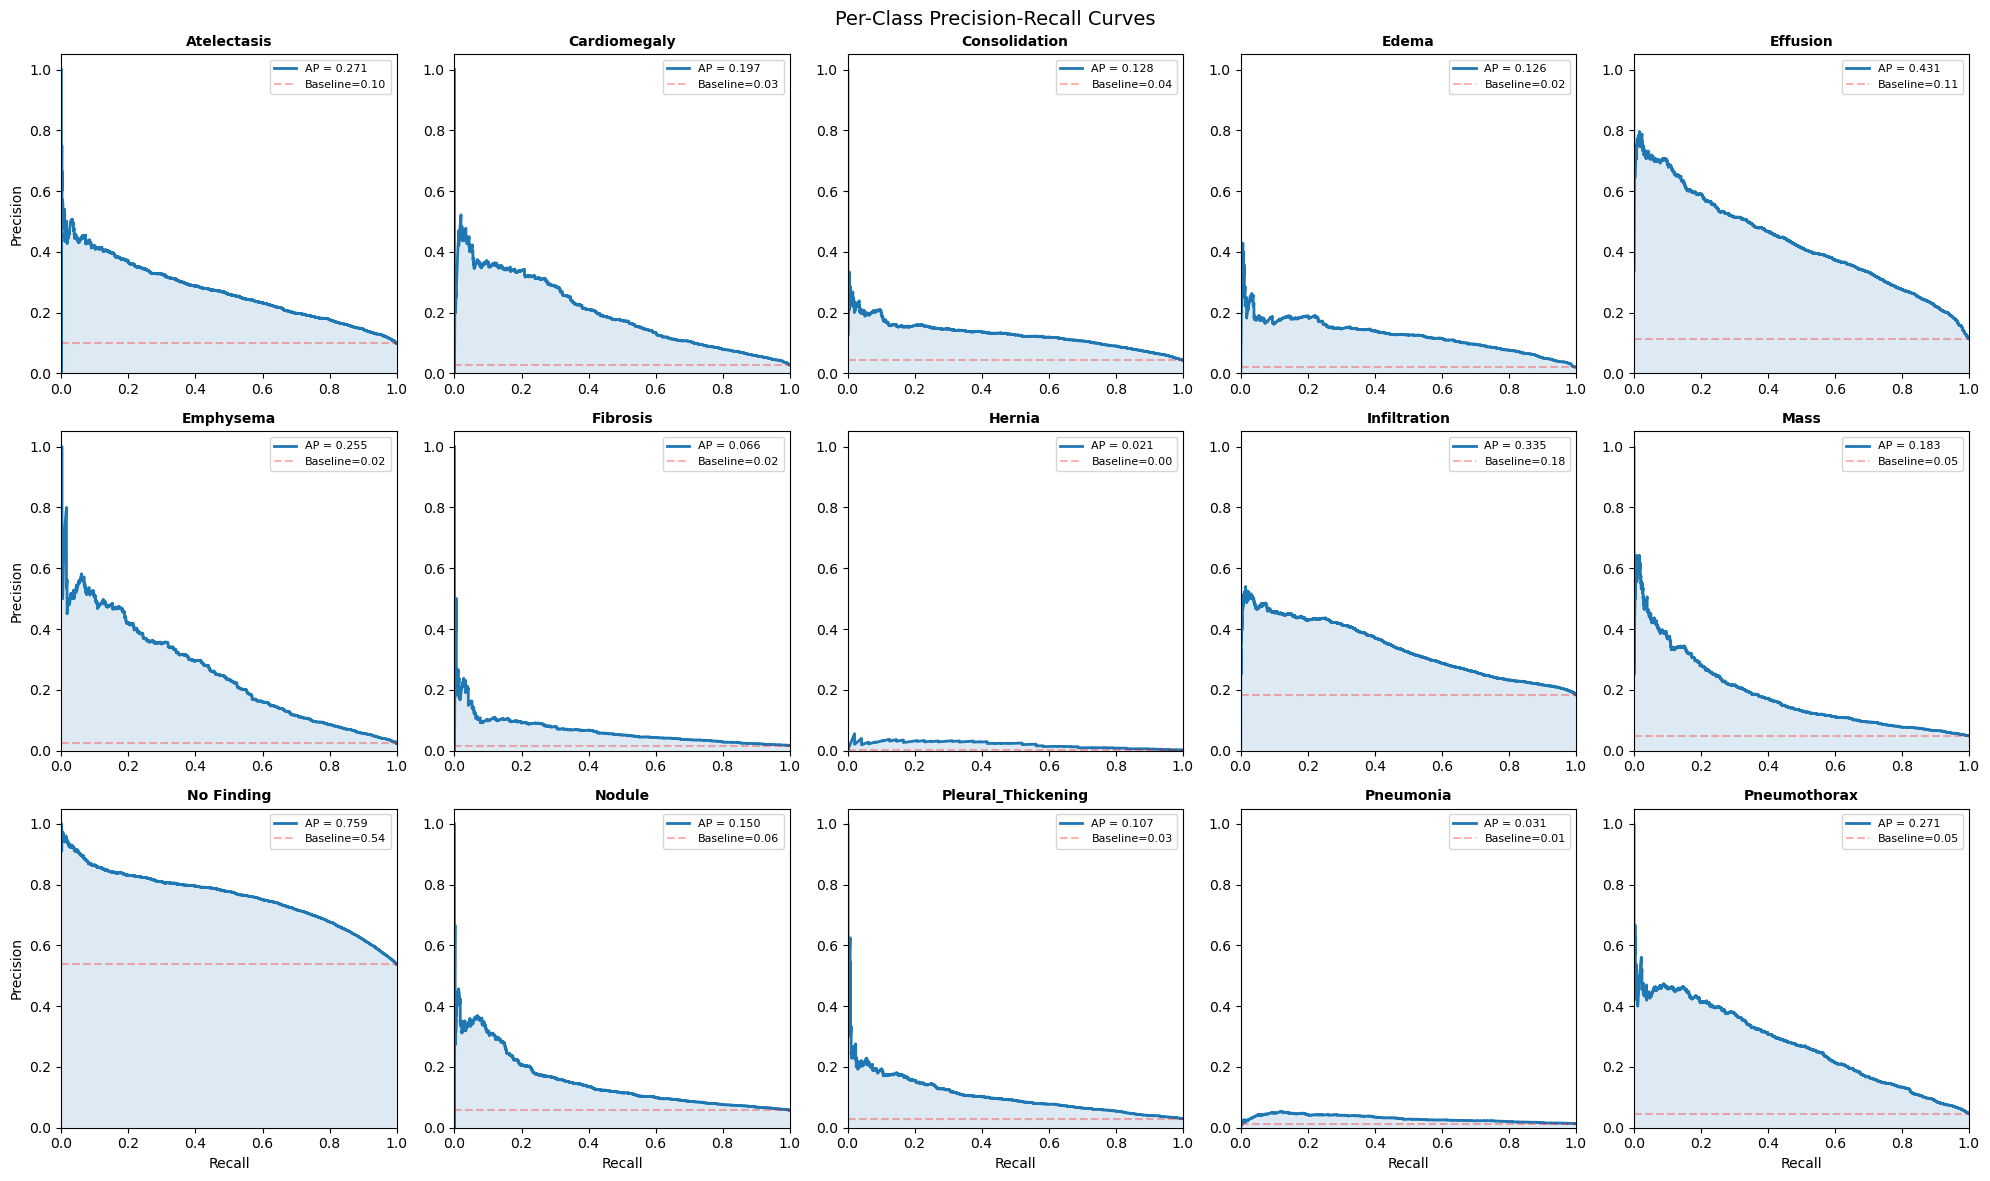

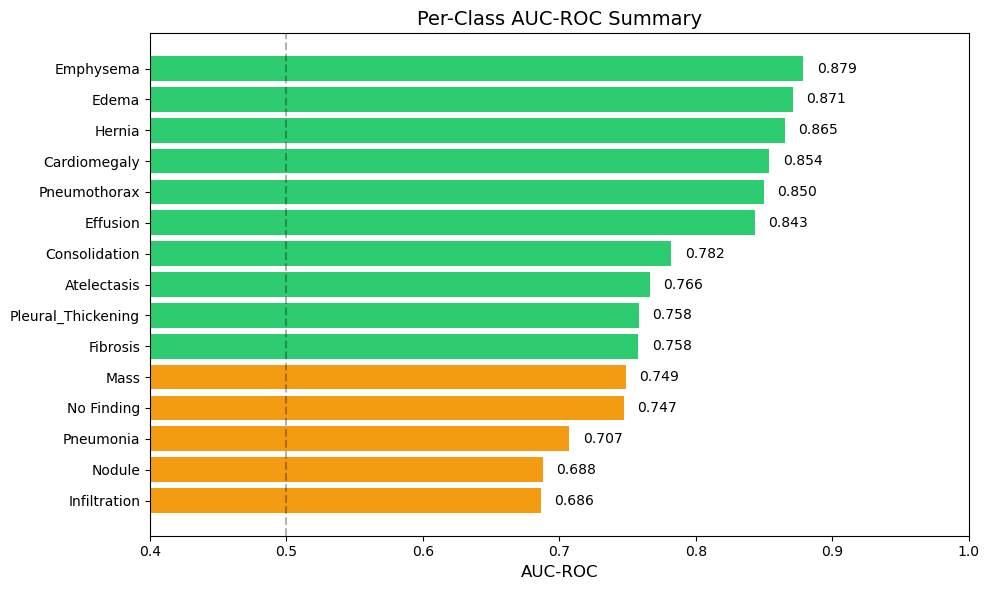

In [13]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Collect all predictions from validation set using best model
checkpoint = torch.load(MODEL_SAVE_PATH, weights_only=False)
model.load_state_dict(checkpoint["state_dict"])
model.eval()

all_labels, all_probs = [], []

with torch.no_grad():
    for batch in val_loader:
        if batch is None:
            continue
        x = batch["image"].to(device)
        y = batch["labels"]
        probs = torch.sigmoid(model(x))
        all_labels.append(y.numpy())
        all_probs.append(probs.cpu().numpy())

all_labels = np.concatenate(all_labels, axis=0)
all_probs = np.concatenate(all_probs, axis=0)
classes = train_ds.classes


# --- 1. Per-Class ROC Curves (the standard figure for this kind of project) ---
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, name in enumerate(classes):
    if i >= len(axes):
        break
    ax = axes[i]
    if len(np.unique(all_labels[:, i])) > 1:
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
        ax.fill_between(fpr, tpr, alpha=0.15)
    else:
        ax.text(0.3, 0.5, "No positive\nsamples", fontsize=10, transform=ax.transAxes)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.legend(loc="lower right", fontsize=9)
    ax.set_xlabel("FPR") if i >= 10 else None
    ax.set_ylabel("TPR") if i % 5 == 0 else None

# Hide unused subplots
for j in range(len(classes), len(axes)):
    axes[j].axis("off")

plt.suptitle("Per-Class ROC Curves", fontsize=14)
plt.tight_layout()
plt.show()


# --- 2. Combined ROC Overlay (good for comparing disease difficulty) ---
plt.figure(figsize=(10, 8))

for i, name in enumerate(classes):
    if len(np.unique(all_labels[:, i])) > 1:
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f"{name} ({roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — All Classes", fontsize=14)
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# --- 3. Precision-Recall Curves (more informative than ROC for imbalanced data) ---
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, name in enumerate(classes):
    if i >= len(axes):
        break
    ax = axes[i]
    if len(np.unique(all_labels[:, i])) > 1:
        precision, recall, _ = precision_recall_curve(all_labels[:, i], all_probs[:, i])
        ap = average_precision_score(all_labels[:, i], all_probs[:, i])
        ax.plot(recall, precision, linewidth=2, label=f"AP = {ap:.3f}")
        ax.fill_between(recall, precision, alpha=0.15)
        # Baseline = prevalence of the class
        prevalence = np.mean(all_labels[:, i])
        ax.axhline(y=prevalence, color="r", linestyle="--", alpha=0.3, label=f"Baseline={prevalence:.2f}")
    else:
        ax.text(0.3, 0.5, "No positive\nsamples", fontsize=10, transform=ax.transAxes)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.legend(loc="upper right", fontsize=8)
    ax.set_xlabel("Recall") if i >= 10 else None
    ax.set_ylabel("Precision") if i % 5 == 0 else None

for j in range(len(classes), len(axes)):
    axes[j].axis("off")

plt.suptitle("Per-Class Precision-Recall Curves", fontsize=14)
plt.tight_layout()
plt.show()


# --- 4. AUC Bar Chart Summary (quick snapshot for a presentation slide) ---
auc_scores = {}
for i, name in enumerate(classes):
    if len(np.unique(all_labels[:, i])) > 1:
        auc_scores[name] = roc_auc_score(all_labels[:, i], all_probs[:, i])

sorted_scores = dict(sorted(auc_scores.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10, 6))
colors = ["#2ecc71" if v >= 0.75 else "#f39c12" if v >= 0.6 else "#e74c3c" for v in sorted_scores.values()]
bars = plt.barh(list(sorted_scores.keys()), list(sorted_scores.values()), color=colors)
plt.xlabel("AUC-ROC", fontsize=12)
plt.title("Per-Class AUC-ROC Summary", fontsize=14)
plt.xlim([0.4, 1.0])
plt.axvline(x=0.5, color="k", linestyle="--", alpha=0.3, label="Random")

for bar, score in zip(bars, sorted_scores.values()):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f"{score:.3f}", va="center", fontsize=10)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()